# Random Forest w/Expanded Features & Weighting Comparison

In [1]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


## 1) Load data

In [2]:
import joblib
import pandas as pd
from scipy import sparse
from pathlib import Path

data_dir = Path("../3_Data_Preprocessing/preprocessing_data")

X_train_sparse = sparse.load_npz(data_dir / "X_train_sparse_rf.npz")
X_test_sparse = sparse.load_npz(data_dir / "X_test_sparse_rf.npz")

y_train = pd.read_csv(data_dir / "y_train_rf.csv").squeeze()
y_test = pd.read_csv(data_dir / "y_test_rf.csv").squeeze()

preprocessor = joblib.load(data_dir / "rf_preprocessor.joblib")

# 2) Train Random Forest (using balanced subsample)

### balanced_subsample -- CLASS IMBALANCE HANDLING
We use class_weight="balanced_subsample" to address class imbalance in the poverty_risk_score labels. Random Forest trains each tree on a bootstrap sample of the training data (a resampled subset). With "balanced_subsample", sklearn recomputes class weights separately for each tree based on that tree’s bootstrap sample class distribution.
Strengths:
 - More robust when bootstrap samples have slightly different class proportions (weights adapt per tree).
 - Often a bit more stable / less aggressive than global reweighting, reducing the risk of over-correcting.
 - Can work well when you want imbalance handling but still want the forest to reflect natural variationacross bootstrap samples.
Weaknesses / tradeoffs:
 - Because weights vary per tree and can be less aggressive overall, minority-class precision/recall gains
   may be smaller than with global "balanced".
 - If minority classes are consistently under-predicted, this approach may not push the model enough.
Practical expectation: Tends to improve minority sensitivity compared to no weighting, while being somewhat conservative.


In [3]:
# RF w/class_weight="balanced_subsample" 
rf_bss = RandomForestClassifier(
    n_estimators=400,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced_subsample", # set to account for class imbalance in povpip
    random_state=42,
    n_jobs=-1
)

rf_bss.fit(X_train_sparse, y_train)

y_pred_bss = rf_bss.predict(X_test_sparse)

print("=== Random Forest Performance ===")
print(classification_report(y_test, y_pred_bss))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_bss))


=== Random Forest Performance ===
              precision    recall  f1-score   support

           0       0.92      0.68      0.78    233793
           1       0.24      0.42      0.30     38456
           2       0.16      0.25      0.19     15534
           3       0.23      0.57      0.33     16585

    accuracy                           0.62    304368
   macro avg       0.39      0.48      0.40    304368
weighted avg       0.76      0.62      0.67    304368

Confusion matrix:
[[158244  43965  12127  19457]
 [  9512  16078   5827   7039]
 [  2623   4780   3909   4222]
 [  1855   2610   2707   9413]]


### balanced -- CLASS IMBALANCE HANDLING
We use class_weight="balanced" to address class imbalance in the poverty_risk_score labels. With "balanced", sklearn computes class weights *once* from the full training set:
weight_c = n_samples / (n_classes * n_samples_in_class_c)
These fixed weights are then applied consistently across all trees in the forest.
Strengths:
- More direct / stronger correction for class imbalance than "balanced_subsample".
- Can improve minority-class performance (often macro F1, sometimes minority precision) because minorityerrors are penalized more uniformly across the whole forest.
- Easier to reason about and reproduce because weights do not vary tree-to-tree.
Weaknesses / tradeoffs:
- Can reduce majority-class recall and sometimes overall accuracy (common when shifting focus to minorities).
- If the true signal separating minority classes is weak, stronger weighting may increase false positives(e.g., predicting higher poverty risk more often).
Practical expectation: Often boosts minority recall/precision somewhat, but may trade off performance on the majority class.


In [6]:
# RF/w class_weight="balanced" 

rf_bal = RandomForestClassifier(
    n_estimators=400,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",   # changed from "balanced_subsample"
    random_state=42,
    n_jobs=-1
)

rf_bal.fit(X_train_sparse, y_train)

y_pred_bal = rf_bal.predict(X_test_sparse)

print("=== Random Forest Performance (class_weight='balanced') ===")
print(classification_report(y_test, y_pred_bal))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_bal))


=== Random Forest Performance (class_weight='balanced') ===
              precision    recall  f1-score   support

           0       0.92      0.68      0.78    233793
           1       0.24      0.42      0.30     38456
           2       0.16      0.25      0.20     15534
           3       0.23      0.57      0.33     16585

    accuracy                           0.62    304368
   macro avg       0.39      0.48      0.40    304368
weighted avg       0.76      0.62      0.67    304368

Confusion matrix:
[[158168  43972  12058  19595]
 [  9481  16120   5832   7023]
 [  2614   4778   3934   4208]
 [  1859   2604   2751   9371]]


## 5) Visualizations of Model Performance

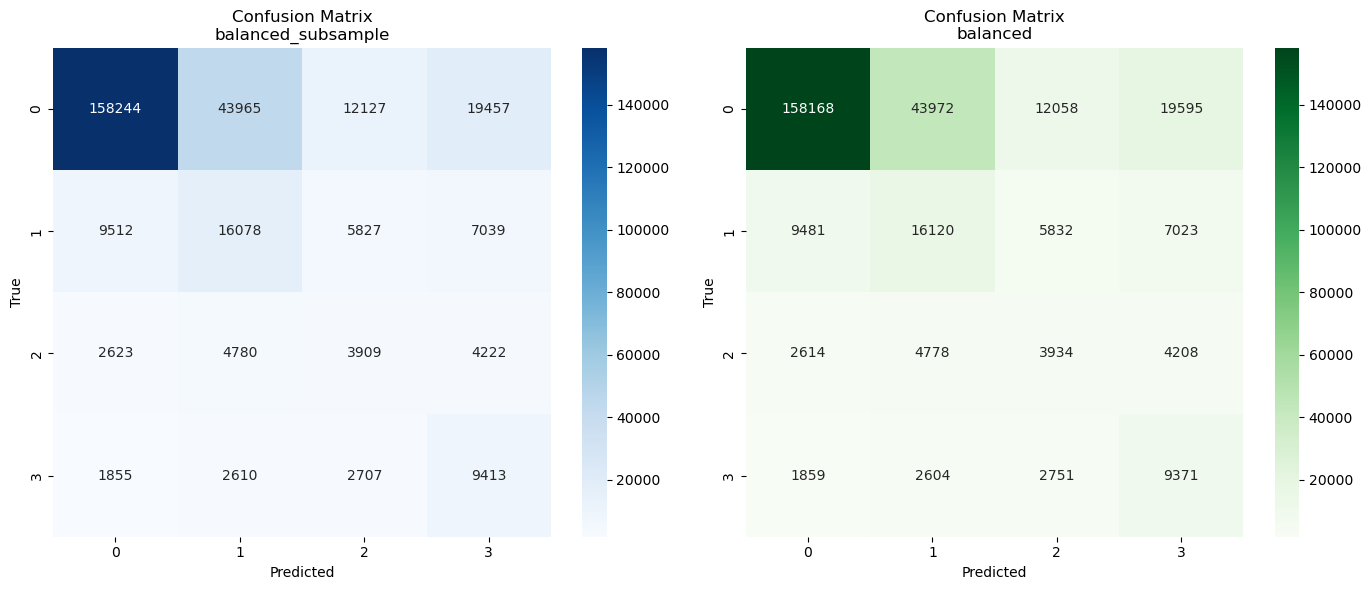

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_sub = confusion_matrix(y_test, y_pred_bss)
cm_bal = confusion_matrix(y_test, y_pred_bal)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm_sub, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix\nbalanced_subsample")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_bal, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Confusion Matrix\nbalanced")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()


In [9]:
import pandas as pd
from sklearn.metrics import classification_report

report_sub = classification_report(y_test, y_pred_bss, output_dict=True)
report_bal = classification_report(y_test, y_pred_bal, output_dict=True)

rows = []

for c in ["0", "1", "2", "3"]:
    rows.append({
        "class": c,
        "precision_subsample": report_sub[c]["precision"],
        "precision_balanced": report_bal[c]["precision"],
        "recall_subsample": report_sub[c]["recall"],
        "recall_balanced": report_bal[c]["recall"],
        "f1_subsample": report_sub[c]["f1-score"],
        "f1_balanced": report_bal[c]["f1-score"],
    })

df_compare = pd.DataFrame(rows)
df_compare


,class,precision_subsample,precision_balanced,recall_subsample,recall_balanced,f1_subsample,f1_balanced
0,0,0.918773,0.918930,0.676855,0.676530,0.779475,0.779316
1,1,0.238429,0.238907,0.418088,0.419180,0.303676,0.304352
2,2,0.159096,0.160081,0.251642,0.253251,0.194943,0.196165
3,3,0.234557,0.233127,0.567561,0.565029,0.331935,0.330069


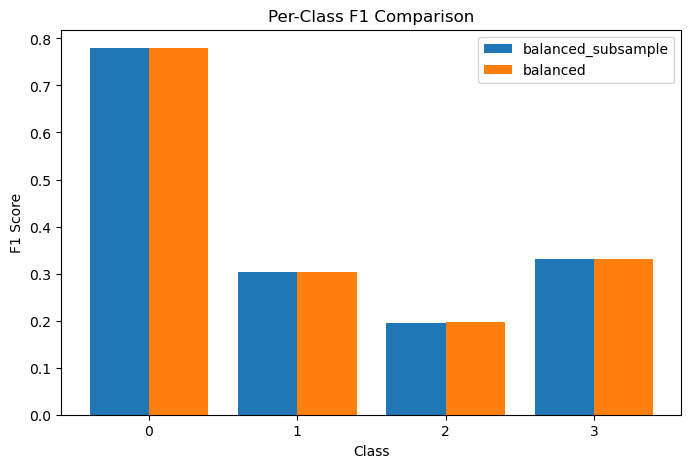

In [10]:
import matplotlib.pyplot as plt

x = range(len(df_compare))

plt.figure(figsize=(8,5))
plt.bar([i-0.2 for i in x], df_compare["f1_subsample"], width=0.4, label="balanced_subsample")
plt.bar([i+0.2 for i in x], df_compare["f1_balanced"], width=0.4, label="balanced")

plt.xticks(x, df_compare["class"])
plt.xlabel("Class")
plt.ylabel("F1 Score")
plt.title("Per-Class F1 Comparison")
plt.legend()
plt.show()


In [11]:
print("Macro F1 (subsample):", report_sub["macro avg"]["f1-score"])
print("Macro F1 (balanced) :", report_bal["macro avg"]["f1-score"])

print("Weighted F1 (subsample):", report_sub["weighted avg"]["f1-score"])
print("Weighted F1 (balanced) :", report_bal["weighted avg"]["f1-score"])


Macro F1 (subsample): 0.40250736172605994
Macro F1 (balanced) : 0.40247565861998447
Weighted F1 (subsample): 0.6651403012202687
Weighted F1 (balanced) : 0.6650639592056318


In [12]:
#Citations to investigate
#Anisha, S. S., Nargunam, A. S., & Shameem, M. (2024). Machine Learning Methods to Predict and Classify Poverty. In Smart Technologies for Sustainable Development Goals (pp. 159-177). CRC Press.
#Hindman, M. (2015). Building better models: Prediction, replication, and machine learning in the social sciences. The Annals of the American Academy of Political and Social Science, 659(1), 48-62.
#Venkatramolla, S. K. (2019). Machine learning and data science for a household-specific poverty level prediction task.

---
## 6) Random Forest on Engineered Feature Set — 4-Class (`poverty_risk_score`)

Using the same engineered CSVs and optimal feature list from `3c_Preprocessing_XGBoost.ipynb`,
but targeting the full 4-class `poverty_risk_score` (0 = Stable, 1 = Near Poverty, 2 = Poverty, 3 = Deep Poverty).

In [1]:
import json
import pandas as pd
from pathlib import Path

data_dir = Path("../3_Data_Preprocessing/preprocessing_data")

# Load engineered train/test sets
df_train_eng = pd.read_csv(data_dir / "train_engineered.csv")
df_test_eng  = pd.read_csv(data_dir / "test_engineered.csv")

# Load feature metadata produced by the XGBoost preprocessing notebook
with open(data_dir / "feature_engineering_metadata.json") as f:
    metadata = json.load(f)

optimal_features = metadata["optimal_features"]

# 4-class target
X_train_4c = df_train_eng[optimal_features]
y_train_4c = df_train_eng["poverty_risk_score"]

X_test_4c = df_test_eng[optimal_features]
y_test_4c = df_test_eng["poverty_risk_score"]

print(f"Optimal features ({len(optimal_features)}): {optimal_features}")
print(f"X_train_4c: {X_train_4c.shape}, y_train_4c: {y_train_4c.shape}")
print(f"X_test_4c:  {X_test_4c.shape},  y_test_4c:  {y_test_4c.shape}")
print(f"\ny_train_4c distribution: {y_train_4c.value_counts().sort_index().to_dict()}")
print(f"y_test_4c  distribution: {y_test_4c.value_counts().sort_index().to_dict()}")

Optimal features (21): ['WKL', 'education_tier', 'MSP', 'WKHP', 'LANX', 'ESR', 'MAR', 'ENG', 'is_latinx', 'CIT', 'MIG', 'has_insurance', 'AGEP', 'SEX', 'OCCP', 'race_white', 'race_black', 'race_asian', 'race_indigenous', 'race_other', 'race_ethnic_aggregate']
X_train_4c: (1469769, 21), y_train_4c: (1469769,)
X_test_4c:  (304368, 21),  y_test_4c:  (304368,)

y_train_4c distribution: {0: 1114746, 1: 196583, 2: 78995, 3: 79445}
y_test_4c  distribution: {0: 233793, 1: 38456, 2: 15534, 3: 16585}


### Random Forest with `balanced_subsample` — 4-class

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [3]:


rf_4c_bss = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf_4c_bss.fit(X_train_4c, y_train_4c)
y_pred_4c_bss = rf_4c_bss.predict(X_test_4c)

print("=== RF (Engineered Features, 4-class, balanced_subsample) ===")
print(classification_report(y_test_4c, y_pred_4c_bss))
print("Confusion matrix:")
print(confusion_matrix(y_test_4c, y_pred_4c_bss))

=== RF (Engineered Features, 4-class, balanced_subsample) ===
              precision    recall  f1-score   support

           0       0.91      0.70      0.79    233793
           1       0.24      0.40      0.30     38456
           2       0.15      0.27      0.19     15534
           3       0.26      0.51      0.34     16585

    accuracy                           0.63    304368
   macro avg       0.39      0.47      0.41    304368
weighted avg       0.75      0.63      0.68    304368

Confusion matrix:
[[164715  40318  13802  14958]
 [ 10899  15538   6412   5607]
 [  3010   4897   4177   3450]
 [  2029   2926   3226   8404]]


### Random Forest with `balanced` — 4-class

In [4]:
rf_4c_bal = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_4c_bal.fit(X_train_4c, y_train_4c)
y_pred_4c_bal = rf_4c_bal.predict(X_test_4c)

print("=== RF (Engineered Features, 4-class, balanced) ===")
print(classification_report(y_test_4c, y_pred_4c_bal))
print("Confusion matrix:")
print(confusion_matrix(y_test_4c, y_pred_4c_bal))

=== RF (Engineered Features, 4-class, balanced) ===
              precision    recall  f1-score   support

           0       0.91      0.71      0.79    233793
           1       0.24      0.40      0.30     38456
           2       0.15      0.27      0.19     15534
           3       0.26      0.51      0.35     16585

    accuracy                           0.63    304368
   macro avg       0.39      0.47      0.41    304368
weighted avg       0.75      0.63      0.68    304368

Confusion matrix:
[[164825  40204  13823  14941]
 [ 10995  15502   6426   5533]
 [  3027   4875   4212   3420]
 [  2042   2837   3238   8468]]


### Visualisations — 4-Class Engineered Feature Models

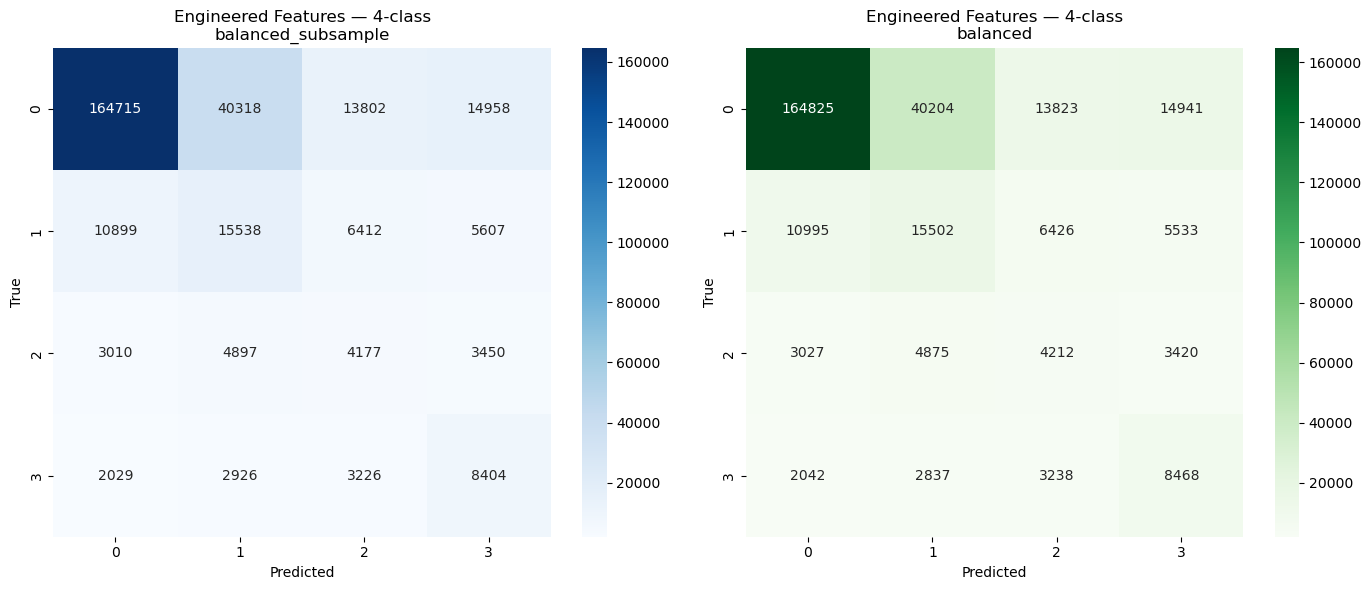

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_4c_bss = confusion_matrix(y_test_4c, y_pred_4c_bss)
cm_4c_bal = confusion_matrix(y_test_4c, y_pred_4c_bal)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm_4c_bss, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Engineered Features — 4-class\nbalanced_subsample")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_4c_bal, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Engineered Features — 4-class\nbalanced")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()

In [6]:
from sklearn.metrics import classification_report

report_4c_bss = classification_report(y_test_4c, y_pred_4c_bss, output_dict=True)
report_4c_bal = classification_report(y_test_4c, y_pred_4c_bal, output_dict=True)

rows = []
for c in ["0", "1", "2", "3"]:
    rows.append({
        "class": c,
        "precision_subsample": report_4c_bss[c]["precision"],
        "precision_balanced":  report_4c_bal[c]["precision"],
        "recall_subsample":    report_4c_bss[c]["recall"],
        "recall_balanced":     report_4c_bal[c]["recall"],
        "f1_subsample":        report_4c_bss[c]["f1-score"],
        "f1_balanced":         report_4c_bal[c]["f1-score"],
    })

df_compare_4c = pd.DataFrame(rows)
display(df_compare_4c)

print(f"\nMacro F1    (balanced_subsample): {report_4c_bss['macro avg']['f1-score']:.4f}")
print(f"Macro F1    (balanced):           {report_4c_bal['macro avg']['f1-score']:.4f}")
print(f"Weighted F1 (balanced_subsample): {report_4c_bss['weighted avg']['f1-score']:.4f}")
print(f"Weighted F1 (balanced):           {report_4c_bal['weighted avg']['f1-score']:.4f}")

,class,precision_subsample,precision_balanced,recall_subsample,recall_balanced,f1_subsample,f1_balanced
0,0,0.911776,0.911194,0.704533,0.705004,0.794868,0.794946
1,1,0.244005,0.244442,0.404046,0.403110,0.304264,0.304337
2,2,0.151247,0.152063,0.268894,0.271147,0.193599,0.194851
3,3,0.259231,0.261665,0.506723,0.510582,0.342992,0.346007



Macro F1    (balanced_subsample): 0.4089
Macro F1    (balanced):           0.4100
Weighted F1 (balanced_subsample): 0.6776
Weighted F1 (balanced):           0.6779


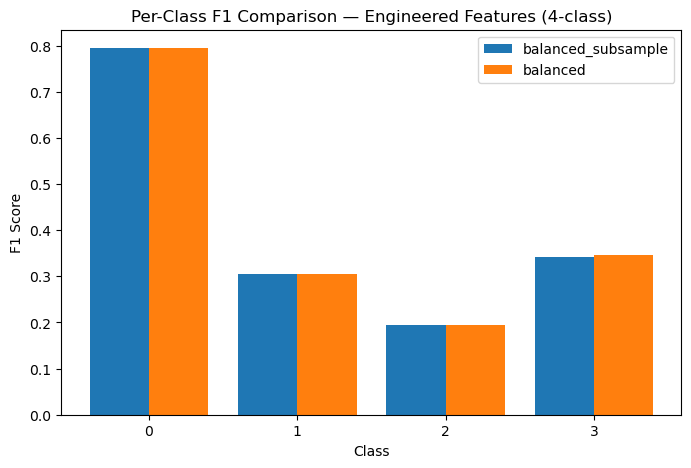

In [7]:
import matplotlib.pyplot as plt

x = range(len(df_compare_4c))

plt.figure(figsize=(8, 5))
plt.bar([i - 0.2 for i in x], df_compare_4c["f1_subsample"], width=0.4, label="balanced_subsample")
plt.bar([i + 0.2 for i in x], df_compare_4c["f1_balanced"],  width=0.4, label="balanced")

plt.xticks(x, df_compare_4c["class"])
plt.xlabel("Class")
plt.ylabel("F1 Score")
plt.title("Per-Class F1 Comparison — Engineered Features (4-class)")
plt.legend()
plt.show()

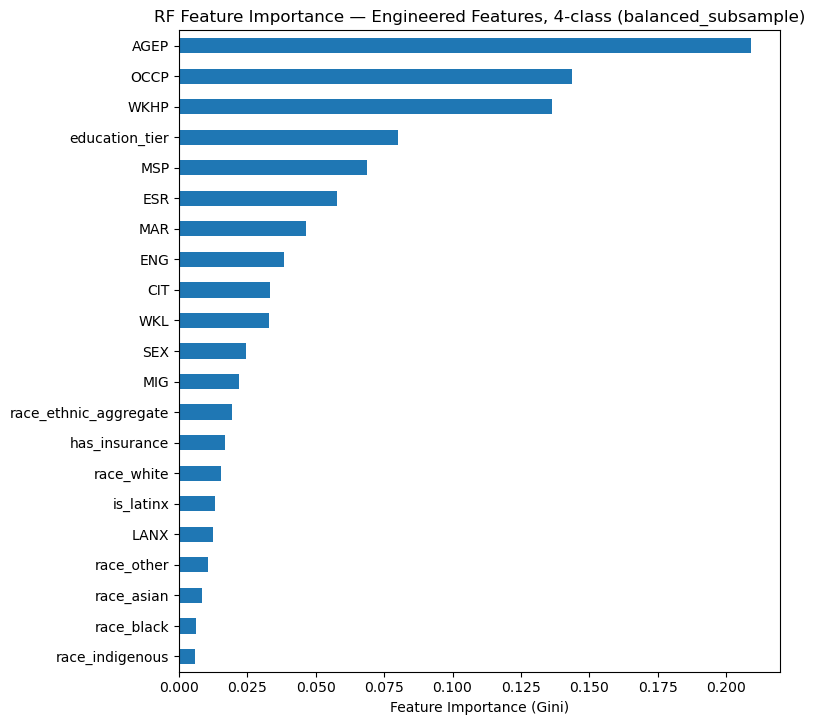

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

importance_4c = pd.Series(
    rf_4c_bss.feature_importances_,
    index=optimal_features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, max(4, len(optimal_features) * 0.35)))
importance_4c.plot(kind="barh", ax=ax)
ax.set_xlabel("Feature Importance (Gini)")
ax.set_title("RF Feature Importance — Engineered Features, 4-class (balanced_subsample)")
plt.tight_layout()
plt.show()

---
## 7) Random Forest on Engineered Feature Set — Binary (`binary_target`)

Using the same engineered CSVs and optimal feature list from `3c_Preprocessing_XGBoost.ipynb`,
targeting the binary `binary_target` label (0 = Stable, 1 = At-Risk).

In [1]:
import json
import pandas as pd
from pathlib import Path

data_dir = Path("../3_Data_Preprocessing/preprocessing_data")

# Load engineered train/test sets
df_train_eng = pd.read_csv(data_dir / "train_engineered.csv")
df_test_eng  = pd.read_csv(data_dir / "test_engineered.csv")

# Load feature metadata produced by the XGBoost preprocessing notebook
with open(data_dir / "feature_engineering_metadata.json") as f:
    metadata = json.load(f)

optimal_features = metadata["optimal_features"]

# Targets
X_train_eng = df_train_eng[optimal_features]
y_train_eng = df_train_eng["binary_target"]

X_test_eng = df_test_eng[optimal_features]
y_test_eng = df_test_eng["binary_target"]

print(f"Optimal features ({len(optimal_features)}): {optimal_features}")
print(f"X_train_eng: {X_train_eng.shape}, y_train_eng: {y_train_eng.shape}")
print(f"X_test_eng:  {X_test_eng.shape},  y_test_eng:  {y_test_eng.shape}")
print(f"\ny_train_eng distribution: {y_train_eng.value_counts().to_dict()}")
print(f"y_test_eng  distribution: {y_test_eng.value_counts().to_dict()}")

Optimal features (21): ['WKL', 'education_tier', 'MSP', 'WKHP', 'LANX', 'ESR', 'MAR', 'ENG', 'is_latinx', 'CIT', 'MIG', 'has_insurance', 'AGEP', 'SEX', 'OCCP', 'race_white', 'race_black', 'race_asian', 'race_indigenous', 'race_other', 'race_ethnic_aggregate']
X_train_eng: (1469769, 21), y_train_eng: (1469769,)
X_test_eng:  (304368, 21),  y_test_eng:  (304368,)

y_train_eng distribution: {0: 1114746, 1: 355023}
y_test_eng  distribution: {0: 233793, 1: 70575}


### Random Forest with `balanced_subsample` on engineered features

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf_eng_bss = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf_eng_bss.fit(X_train_eng, y_train_eng)
y_pred_eng_bss = rf_eng_bss.predict(X_test_eng)

print("=== RF (Engineered Features, balanced_subsample) ===")
print(classification_report(y_test_eng, y_pred_eng_bss))
print("Confusion matrix:")
print(confusion_matrix(y_test_eng, y_pred_eng_bss))

=== RF (Engineered Features, balanced_subsample) ===
              precision    recall  f1-score   support

           0       0.90      0.75      0.82    233793
           1       0.47      0.72      0.57     70575

    accuracy                           0.75    304368
   macro avg       0.69      0.74      0.70    304368
weighted avg       0.80      0.75      0.76    304368

Confusion matrix:
[[176462  57331]
 [ 19599  50976]]


### Random Forest with `balanced` on engineered features

In [7]:
rf_eng_bal = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_eng_bal.fit(X_train_eng, y_train_eng)
y_pred_eng_bal = rf_eng_bal.predict(X_test_eng)

print("=== RF (Engineered Features, balanced) ===")
print(classification_report(y_test_eng, y_pred_eng_bal))
print("Confusion matrix:")
print(confusion_matrix(y_test_eng, y_pred_eng_bal))

=== RF (Engineered Features, balanced) ===
              precision    recall  f1-score   support

           0       0.90      0.75      0.82    233793
           1       0.47      0.72      0.57     70575

    accuracy                           0.75    304368
   macro avg       0.69      0.74      0.70    304368
weighted avg       0.80      0.75      0.76    304368

Confusion matrix:
[[176452  57341]
 [ 19535  51040]]


### Visualisations — Engineered Feature Models

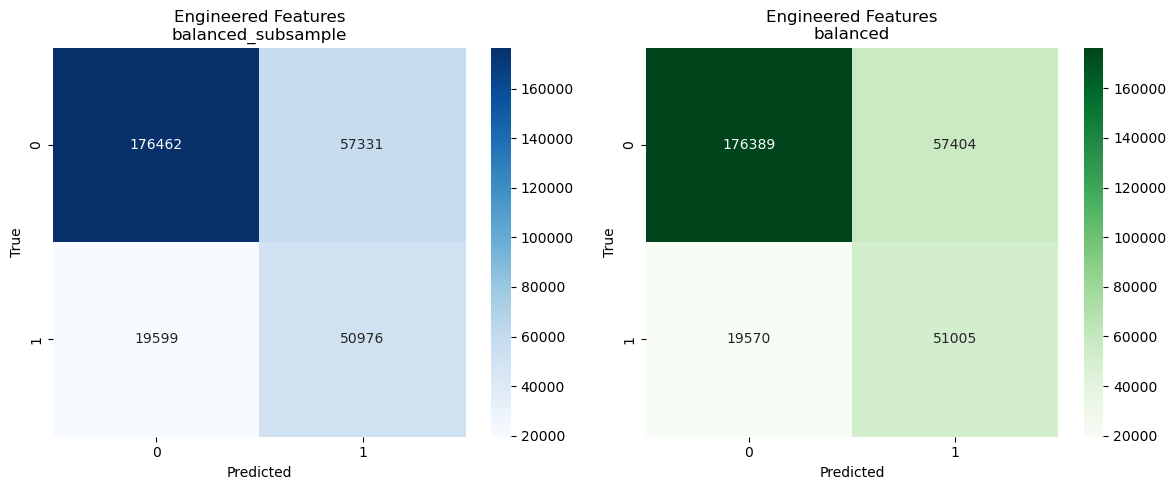

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_eng_bss = confusion_matrix(y_test_eng, y_pred_eng_bss)
cm_eng_bal = confusion_matrix(y_test_eng, y_pred_eng_bal)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_eng_bss, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Engineered Features\nbalanced_subsample")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_eng_bal, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Engineered Features\nbalanced")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()

In [5]:
from sklearn.metrics import classification_report, f1_score

report_eng_bss = classification_report(y_test_eng, y_pred_eng_bss, output_dict=True)
report_eng_bal = classification_report(y_test_eng, y_pred_eng_bal, output_dict=True)

rows = []
for c in ["0", "1"]:
    rows.append({
        "class": c,
        "precision_subsample": report_eng_bss[c]["precision"],
        "precision_balanced":  report_eng_bal[c]["precision"],
        "recall_subsample":    report_eng_bss[c]["recall"],
        "recall_balanced":     report_eng_bal[c]["recall"],
        "f1_subsample":        report_eng_bss[c]["f1-score"],
        "f1_balanced":         report_eng_bal[c]["f1-score"],
    })

df_compare_eng = pd.DataFrame(rows)
print(df_compare_eng.to_string(index=False))

print(f"\nMacro F1 (balanced_subsample): {report_eng_bss['macro avg']['f1-score']:.4f}")
print(f"Macro F1 (balanced):           {report_eng_bal['macro avg']['f1-score']:.4f}")
print(f"Weighted F1 (balanced_subsample): {report_eng_bss['weighted avg']['f1-score']:.4f}")
print(f"Weighted F1 (balanced):           {report_eng_bal['weighted avg']['f1-score']:.4f}")

class  precision_subsample  precision_balanced  recall_subsample  recall_balanced  f1_subsample  f1_balanced
    0             0.900036            0.900132          0.754779         0.754467      0.821032     0.820887
    1             0.470662            0.470487          0.722295         0.722706      0.569940     0.569939

Macro F1 (balanced_subsample): 0.6955
Macro F1 (balanced):           0.6954
Weighted F1 (balanced_subsample): 0.7628
Weighted F1 (balanced):           0.7627


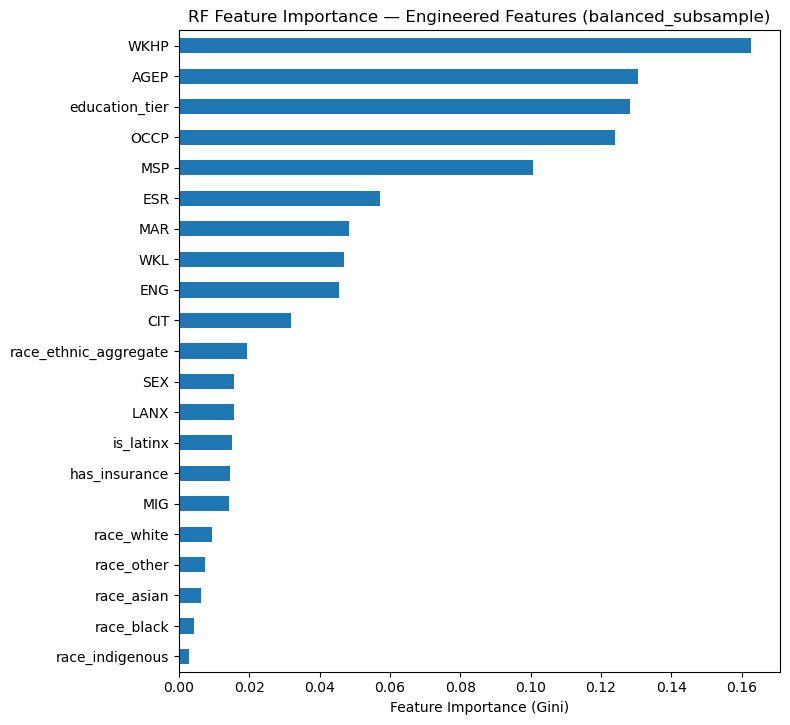

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance from the balanced_subsample model
importance_eng = pd.Series(
    rf_eng_bss.feature_importances_,
    index=optimal_features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, max(4, len(optimal_features) * 0.35)))
importance_eng.plot(kind="barh", ax=ax)
ax.set_xlabel("Feature Importance (Gini)")
ax.set_title("RF Feature Importance — Engineered Features (balanced_subsample)")
plt.tight_layout()
plt.show()